In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import imageio
import uuid
from PIL import Image as PILImage
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import Image as ImageDisplay
from inference import Inference, ready_gaussian_for_video_rendering, render_video, load_image, load_single_mask, display_image, make_scene, interactive_visualizer

2026-03-06 15:50:29.193 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is NVIDIA H100 80GB HBM3


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-03-06 15:50:31.132 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: flash_attn
2026-03-06 15:50:34.545 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: flash_attn


[SPARSE][CONV] spconv algo: auto


2026-03-06 15:50:36.012 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-06 15:50:36.014 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


In [2]:
config_path = "/robodata/smodak/repos/sam-3d-objects/checkpoints/hf/pipeline.yaml"
inference = Inference(config_path, compile=False)

2026-03-06 15:50:36.170 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-06 15:50:58.940 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-06 15:50:58.944 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:100 - self.device: cuda
2026-03-06 15:50:58.945 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:101 - CUDA_VISIBLE_DEVICES: 1
2026-03-06 15:50:58.945 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:102 - Actually using GPU: 0
2026-03-06 15:50:58.945 | INFO     | sam3d_objects.pipeline.inference_pipeline:init_pose_decoder:297 - Using pose decoder: ScaleShiftInvariant
2026-03-06 15:50:58.946 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:133 - Loading model weights...
2026-03-06 15:50:59.363 | INFO     | sam3d_objects.model.io:load_model_fro

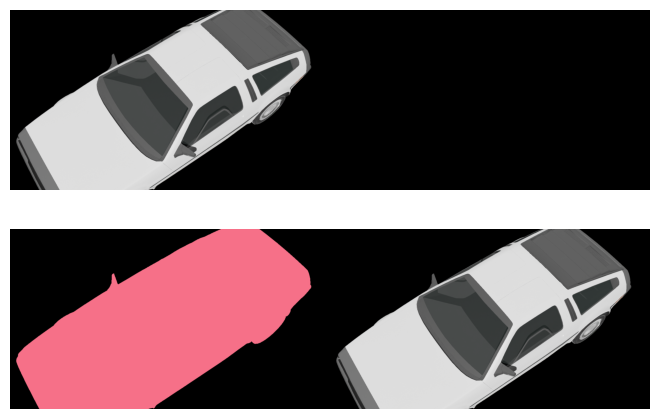

In [3]:
imgpath = "/robodata/smodak/repos/f3rm/datasets/f3rm/opt/objaverse/car2/images/frame_00057.png"
maskpath = "/robodata/smodak/repos/f3rm/datasets/f3rm/opt/objaverse/car2/object_masks/frame_00057.png"
image = np.asarray(PILImage.open(imgpath).convert("RGB"))
mask = np.asarray(PILImage.open(maskpath)).astype(bool)
display_image(image, masks=[mask])


In [4]:
# run model
output = inference(image, mask, seed=42)

# export gaussian splat (as point cloud)
output["gs"].save_ply("test.ply")

2026-03-06 15:54:36.040 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:664 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-03-06 15:54:36.041 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:633 - Running condition embedder ...
2026-03-06 15:54:36.202 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Condition embedder finishes!
2026-03-06 15:54:41.651 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:714 - Downsampled coords from 8428 to 8412
2026-03-06 15:54:41.705 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:437 - Rescaling scale by 1 after downsampling
2026-03-06 15:54:41.706 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:744 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-03-06 15:54:41.707 | INFO     | sam3d

In [5]:
# might take a while to load (black screen)
interactive_visualizer("test.ply")

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://539222b6b2eab92f53.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [6]:
output.keys()

dict_keys(['6drotation_normalized', 'scale', 'shape', 'translation', 'translation_scale', 'coords_original', 'coords', 'downsample_factor', 'rotation', 'mesh', 'gaussian', 'glb', 'gs', 'pointmap', 'pointmap_colors'])

In [7]:
output['pointmap_colors'].shape

torch.Size([360, 640, 3])

In [8]:
image.shape

(720, 1280, 3)

In [9]:
scene_gs = make_scene(output)

In [10]:
scene_gs.save_ply("test_scene.ply")

In [11]:
interactive_visualizer("test_scene.ply")

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://500fa8e7368de3f9e7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
scene_gs.get_xyz.shape

torch.Size([269184, 3])

In [13]:
rgba = inference.merge_mask_to_rgba(image, mask)
pm = inference._pipeline.compute_pointmap(rgba)   # internal call
full_pointmap_chw = pm["pointmap"]                # (3, H, W)
full_pointmap_hwc = full_pointmap_chw.permute(1, 2, 0).cpu().numpy()

In [14]:
full_pointmap_hwc.shape

(720, 1280, 3)

In [15]:
image.shape

(720, 1280, 3)

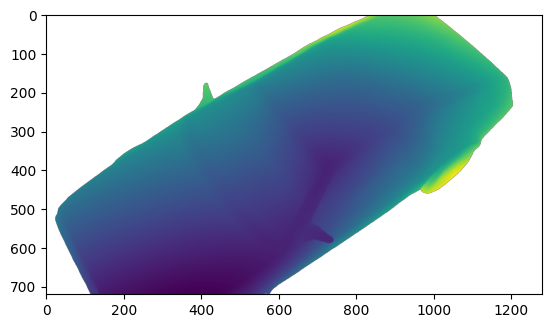

In [32]:
plt.imshow(full_pointmap_hwc[...,2])

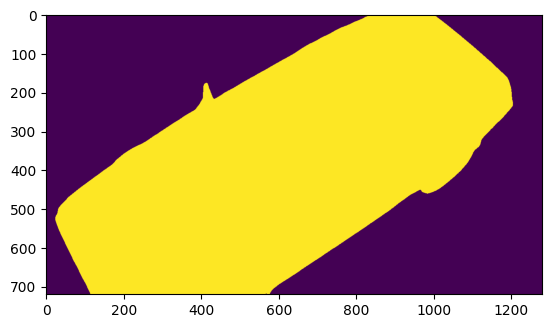

In [16]:
plt.imshow(~np.isnan(full_pointmap_hwc)[:,:,0])

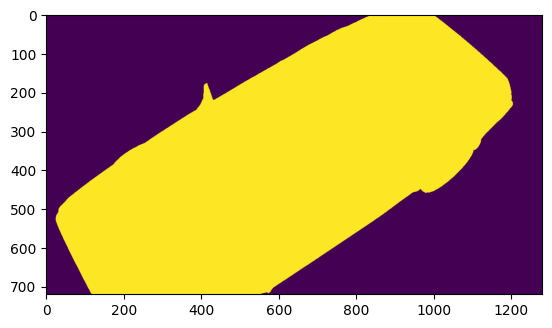

In [17]:
plt.imshow(mask)

In [18]:
scene_gs.get_xyz.shape

torch.Size([269184, 3])

In [19]:
output['gs'].get_xyz.shape

torch.Size([269184, 3])

In [ ]:
interactive_visualizer('/robodata/smodak/repos/f3rm/datasets/f3rm/fresh/objaverse/car2new/features/sam3d_/reconstructions/frame_00022/instances/instance_000/gs_local.ply')